<a href="https://colab.research.google.com/github/Priyan437/SMS_SPAM_CLASSIFIER/blob/colab/spamclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
661,ham,Then mum's repent how?,NaN,NaN,NaN
74,ham,U can call me now...,NaN,NaN,NaN


In [15]:
df.shape

(5572, 5)

In [16]:
# Line of Action

# Data Cleaning
# EDA
# Feature Engineering
# Text Preprocessing
# Model Building
# Evaluation
# Improvement


In [17]:
#1 Data Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [18]:
# Since very few non null values is present in the last three columns it is dropped as of no use.

df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'],inplace = True)
df.sample(5)

,v1,v2
554,ham,IÛ÷ll have a look at the frying pan in case i...
4350,ham,"Night has ended for another day, morning has c..."
8,spam,WINNER!! As a valued network customer you have...
580,ham,Huh so early.. Then Ì_ having dinner outside i...
3155,ham,Long time. You remember me today.


In [19]:
# Renaming the Columns

df.rename(columns={'v1':'target','v2':'text'},inplace = True)
df.sample(5)

,target,text
2457,ham,K.k..how is your sister kids?
5375,ham,I cant pick the phone right now. Pls send a me...
3090,spam,LORD OF THE RINGS:RETURN OF THE KING in store ...
4063,ham,Prof: you have passed in all the papers in thi...
4748,ham,Thanx u darlin!im cool thanx. A few bday drink...


In [20]:
# Turning the target column into classes

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [21]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(2)

,target,text
5259,0,Can help u swoop by picking u up from wherever...
3781,0,How r Ì_ going to send it to me?


In [22]:
df.isnull().sum()

,0
target,0
text,0


In [27]:
#checking of the Duplicate value

df.duplicated().sum()

np.int64(0)

In [28]:
#Dropping the Duplicate Value

df.drop_duplicates(keep = 'first',inplace = True)

In [29]:
df.shape

(5169, 2)

In [31]:
# 2. EDA

In [39]:
# Checking the Percentage of Spam and Non-Spam
p_not_spam = df[df['target'] == 0].shape[0]/df['target'].shape[0] *100
print('Percentage of not Spam is :',p_not_spam)
print('Percentage of Spam is :',(100 - p_not_spam))

Percentage of not Spam is : 87.3669955503966
Percentage of Spam is : 12.633004449603405


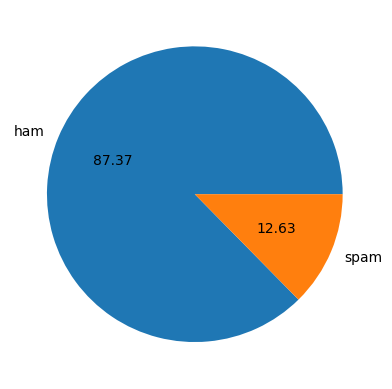

In [40]:
plt.pie(df['target'].value_counts(), labels = ['ham','spam'], autopct ="%0.2f")
plt.show()

In [41]:
pip install nltk

In [47]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [45]:
# Number of Characters in each message count

df['num_character'] = df['text'].apply(len)
df.sample(2)

,target,text,num_character
161,0,New car and house for my parents.:)i have only...,64
5181,0,K sure am in my relatives home. Sms me de. Pls:-),49


In [50]:
# Number of Words in each message count

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words
5295,0,Alex says he's not ok with you not being ok wi...,51,13
4178,0,Can Ì_ send me a copy of da report?,35,10


In [51]:
# No of sentence in each message count

df['num_sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words,num_sent
1370,0,Hope you are feeling great. Pls fill me in. Ab...,50,12,3
215,0,Finally the match heading towards draw as your...,58,10,1


In [54]:
# Complete Overview of all messages character count, Sentence Count,sentence count
df[['num_character','num_words','num_sent']].describe()


,num_character,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [55]:
# no of ham messages overview

df[df['target'] == 0][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [56]:
# no of spam messages overview

df[df['target'] == 1][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_character', ylabel='Count'>

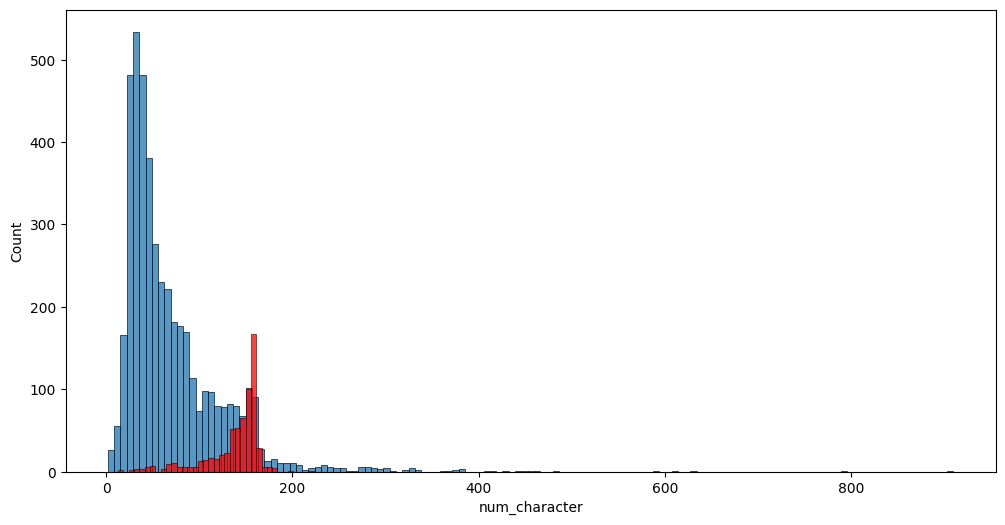

In [58]:
# We can observe that the spam messages is larger as compared to the not spam messages
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'],color='red')

<Axes: xlabel='num_sent', ylabel='Count'>

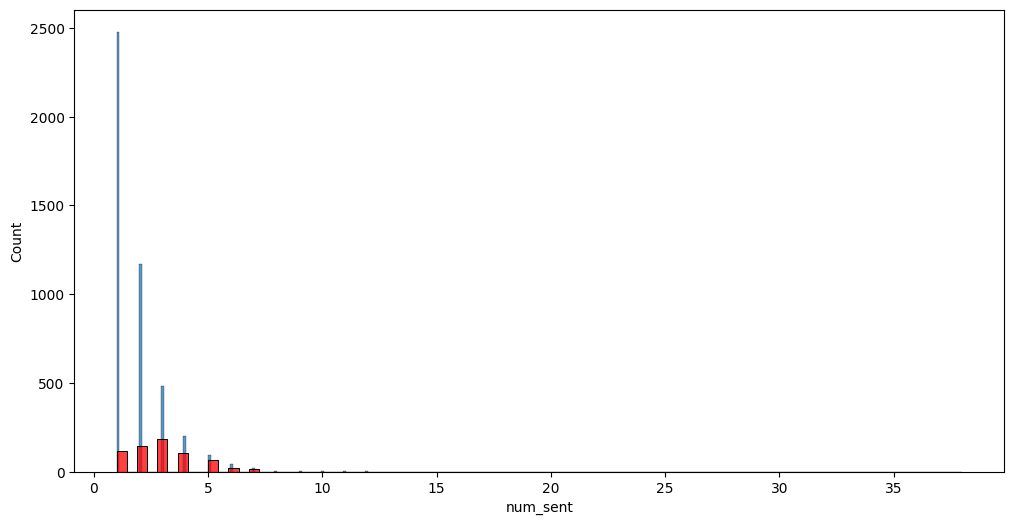

In [59]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sent'])
sns.histplot(df[df['target'] == 1]['num_sent'],color='red')

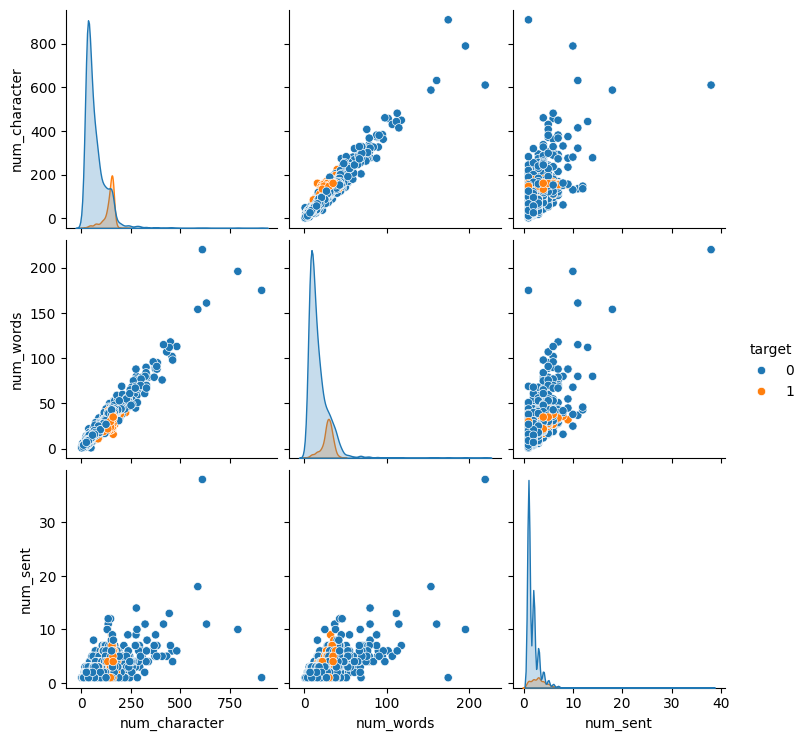

In [60]:
sns.pairplot(df,hue='target')

<Axes: >

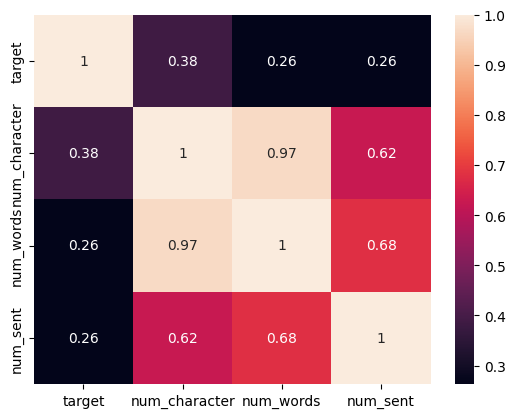

In [62]:
sns.heatmap(df[['target','num_character','num_words','num_sent']].corr(),annot=True)